# Animal Image Classification — ResNet18 Transfer Learning

This notebook is prepared for the Deep Learning final project.

**Task:** classify animal images into 15 classes using a convolutional neural network.

Dataset structure expected:

```text
animal_data/
    Bear/
    Bird/
    Cat/
    Cow/
    Deer/
    Dog/
    ...
```

Important final requirement: the notebook contains a separate **Load and Predict** section that loads the saved model and predicts without retraining.


In [1]:
# ============================================
# Animal Image Classification with ResNet18
# Deep Learning Final Project
# Dataset structure:
# animal_data/
#   Bear/
#   Bird/
#   Cat/
#   ...

In [2]:
# ============================================
import random
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms, models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


In [3]:
# ============================================
# 1. Settings

In [4]:
# ============================================
# IMPORTANT:
# Put here the path to the folder that contains class folders:
# Bear, Bird, Cat, Cow, Deer, Dog, Dolphin, ...
#
# If animal_data is in the same folder as this notebook/script:
DATA_DIR = Path("animal_data")  # place animal_data next to this notebook

# Example for Windows:
# DATA_DIR = Path(r"C:\Users\aitzh\OneDrive\Desktop\deep learning\animal_data")



IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001
VAL_SPLIT = 0.20
MODEL_PATH = Path("animal_resnet18_checkpoint.pth")
RANDOM_SEED = 42

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [5]:
# ============================================
# 2. Reproducibility

In [6]:
# ============================================
def set_seed(seed: int = 42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

In [7]:
# ============================================
# 3. Check Dataset Path

In [8]:
# ============================================
if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"DATA_DIR does not exist: {DATA_DIR}\n"
        "Change DATA_DIR to the folder that contains animal class folders."
    )

folders = [p.name for p in DATA_DIR.iterdir() if p.is_dir()]
print("Folders found:", folders)

if len(folders) == 0:
    raise ValueError("No class folders found inside DATA_DIR.")

Folders found: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']


In [9]:
# ============================================
# 4. Transforms

In [10]:
# ============================================
# ResNet18 pretrained on ImageNet expects ImageNet normalization.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [11]:
# ============================================
# 5. Dataset and DataLoaders

In [12]:
# ============================================
# Base dataset only for classes and splitting
base_dataset = datasets.ImageFolder(root=DATA_DIR)
class_names = base_dataset.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Total images:", len(base_dataset))

# Create fixed train/validation split indices
val_size = int(len(base_dataset) * VAL_SPLIT)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_subset_base, val_subset_base = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

train_indices = train_subset_base.indices
val_indices = val_subset_base.indices

# Same images, different transforms
train_full = datasets.ImageFolder(root=DATA_DIR, transform=train_transform)
val_full = datasets.ImageFolder(root=DATA_DIR, transform=val_transform)

train_dataset = Subset(train_full, train_indices)
val_dataset = Subset(val_full, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']
Number of classes: 15
Total images: 1944
Train images: 1556
Validation images: 388
Train batches: 49
Validation batches: 13


In [13]:
# ============================================
# 6. Show One Sample Image

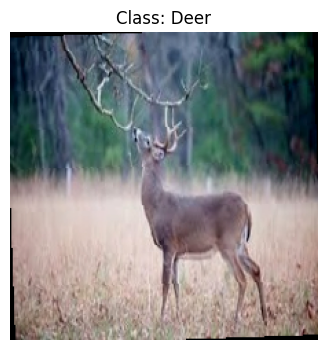

In [14]:
# ============================================
def imshow_tensor(image_tensor, title=None):
    """Denormalize and display a tensor image."""
    image = image_tensor.clone().detach().cpu()
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    image = image * std + mean
    image = torch.clamp(image, 0, 1)
    image = image.permute(1, 2, 0).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
imshow_tensor(images[0], title=f"Class: {class_names[labels[0].item()]}")

In [15]:
# ============================================
# 7. Build ResNet18 Transfer Learning Model

In [16]:
# ============================================
def build_resnet18_model(num_classes: int, pretrained: bool = True, freeze_backbone: bool = True):
    """
    Builds ResNet18 model.
    pretrained=True downloads ImageNet weights if available.
    freeze_backbone=True trains only final classification layer.
    """
    if pretrained:
        try:
            weights = models.ResNet18_Weights.DEFAULT
            model = models.resnet18(weights=weights)
            print("Loaded pretrained ResNet18 weights.")
        except AttributeError:
            # For older torchvision versions
            model = models.resnet18(pretrained=True)
            print("Loaded pretrained ResNet18 weights using old torchvision API.")
        except Exception as e:
            print("Could not load pretrained weights.")
            print("Reason:", e)
            print("Using ResNet18 without pretrained weights.")
            try:
                model = models.resnet18(weights=None)
            except TypeError:
                model = models.resnet18(pretrained=False)
    else:
        try:
            model = models.resnet18(weights=None)
        except TypeError:
            model = models.resnet18(pretrained=False)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final layer for our animal classes
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model


def count_trainable_parameters(model):
    """Return the total number of trainable parameters in the model."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model = build_resnet18_model(
    num_classes=num_classes,
    pretrained=True,
    freeze_backbone=True
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = count_trainable_parameters(model)

print(model)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loaded pretrained ResNet18 weights.
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affin

In [17]:
# ============================================
# 8. Loss, Optimizer, Metric

In [18]:
# ============================================
criterion = nn.CrossEntropyLoss()

# Only parameters with requires_grad=True will be trained.
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)


def calculate_accuracy(logits, labels):
    """Return the fraction of correct predictions for a single batch."""
    preds = torch.argmax(logits, dim=1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [19]:
# ============================================
# 9. Training and Validation Functions

In [20]:
# ============================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns (avg_loss, accuracy) over the loader."""
    model.train()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(logits, dim=1)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    """Evaluate model on loader without gradient updates. Returns (avg_loss, accuracy)."""
    model.eval()

    running_loss = 0.0
    running_correct = 0
    running_total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(logits, dim=1)
            running_correct += (preds == labels).sum().item()
            running_total += labels.size(0)

    epoch_loss = running_loss / running_total
    epoch_acc = running_correct / running_total

    return epoch_loss, epoch_acc

In [21]:
# ============================================
# 10. Train Model

In [22]:
# ============================================
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_val_acc = 0.0

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | "
        f"Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}"
    )

    # Save best model checkpoint (criterion: highest val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            "model_name": "resnet18_transfer_learning",
            "model_state_dict": model.state_dict(),
            "class_names": class_names,
            "num_classes": num_classes,
            "img_size": IMG_SIZE,
            "mean": IMAGENET_MEAN,
            "std": IMAGENET_STD,
            "best_val_acc": best_val_acc,
        }, MODEL_PATH)

print("Best validation accuracy:", round(best_val_acc, 4))
print("Saved model to:", MODEL_PATH)

Epoch 01/10 | Train loss: 1.8342, Train acc: 0.5141 | Val loss: 1.0735, Val acc: 0.7912
Epoch 02/10 | Train loss: 0.8410, Train acc: 0.8554 | Val loss: 0.6476, Val acc: 0.8711
Epoch 03/10 | Train loss: 0.5553, Train acc: 0.9113 | Val loss: 0.5047, Val acc: 0.8969
Epoch 04/10 | Train loss: 0.4228, Train acc: 0.9357 | Val loss: 0.4227, Val acc: 0.9072
Epoch 05/10 | Train loss: 0.3518, Train acc: 0.9422 | Val loss: 0.3426, Val acc: 0.9175
Epoch 06/10 | Train loss: 0.3165, Train acc: 0.9402 | Val loss: 0.3170, Val acc: 0.9278
Epoch 07/10 | Train loss: 0.2629, Train acc: 0.9531 | Val loss: 0.3121, Val acc: 0.9201
Epoch 08/10 | Train loss: 0.2427, Train acc: 0.9569 | Val loss: 0.2646, Val acc: 0.9433
Epoch 09/10 | Train loss: 0.2289, Train acc: 0.9557 | Val loss: 0.2758, Val acc: 0.9175
Epoch 10/10 | Train loss: 0.2055, Train acc: 0.9544 | Val loss: 0.2597, Val acc: 0.9278
Best validation accuracy: 0.9433
Saved model to: animal_resnet18_checkpoint.pth


In [23]:
# ============================================
# 11. Plot Training Results

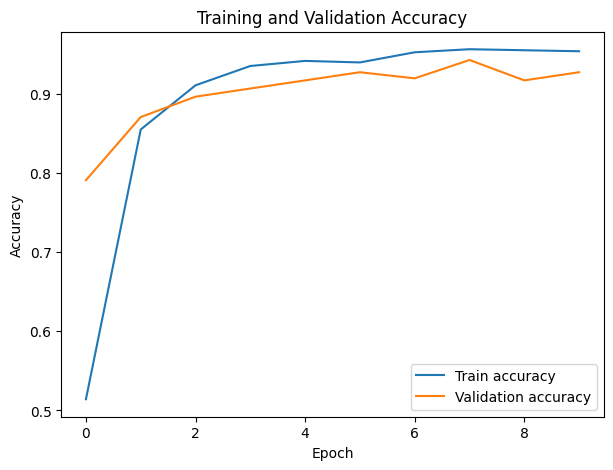

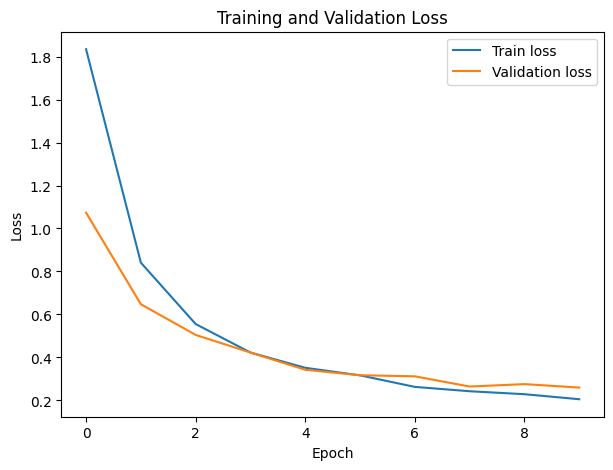

In [24]:
# ============================================
plt.figure(figsize=(7, 5))
plt.plot(history["train_acc"], label="Train accuracy")
plt.plot(history["val_acc"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train loss")
plt.plot(history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

F1 Score (weighted): 0.9283
F1 Score (macro):    0.9259


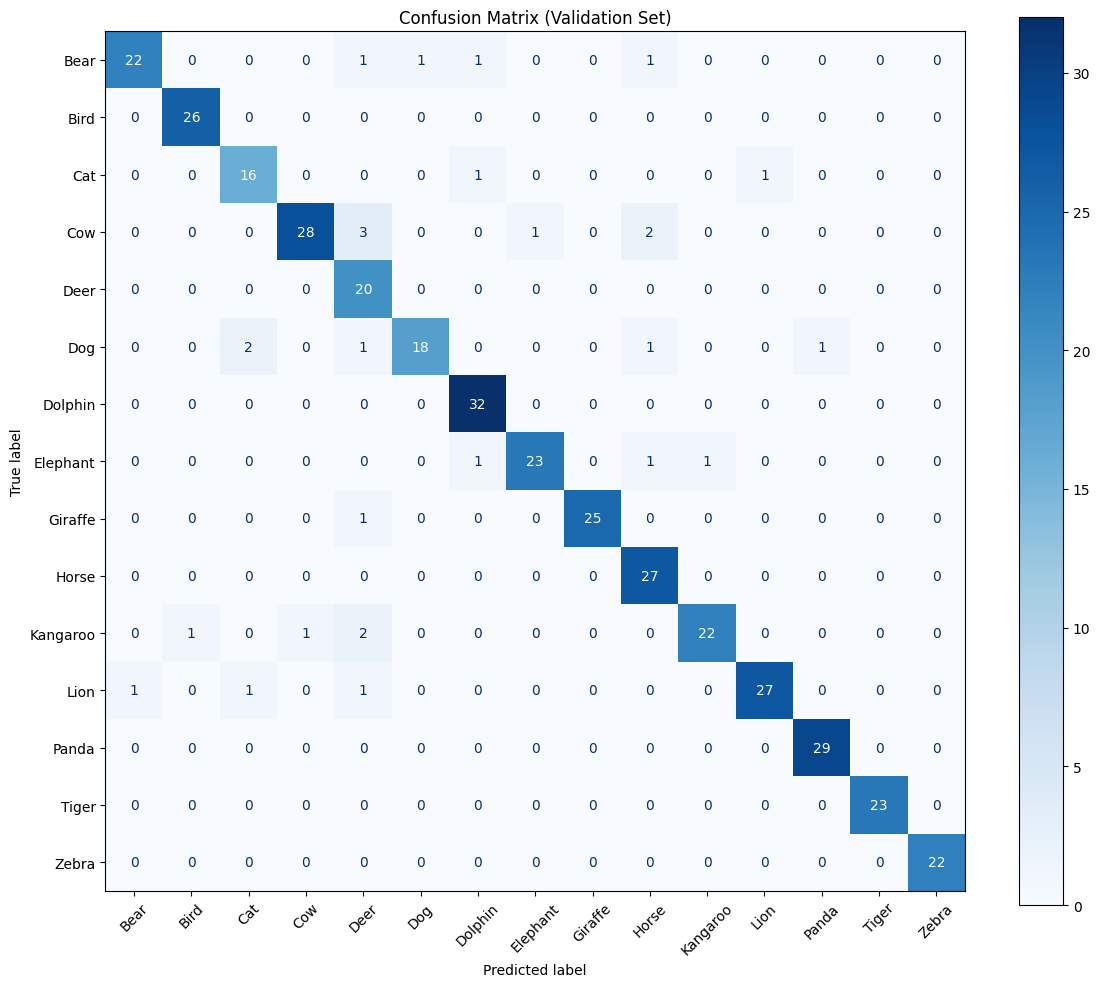


Classification Report:

              precision    recall  f1-score   support

        Bear       0.96      0.85      0.90        26
        Bird       0.96      1.00      0.98        26
         Cat       0.84      0.89      0.86        18
         Cow       0.97      0.82      0.89        34
        Deer       0.69      1.00      0.82        20
         Dog       0.95      0.78      0.86        23
     Dolphin       0.91      1.00      0.96        32
    Elephant       0.96      0.88      0.92        26
     Giraffe       1.00      0.96      0.98        26
       Horse       0.84      1.00      0.92        27
    Kangaroo       0.96      0.85      0.90        26
        Lion       0.96      0.90      0.93        30
       Panda       0.97      1.00      0.98        29
       Tiger       1.00      1.00      1.00        23
       Zebra       1.00      1.00      1.00        22

    accuracy                           0.93       388
   macro avg       0.93      0.93      0.93       388
w

In [25]:
# ============================================
# 11b. F1 Score and Confusion Matrix
# ============================================
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def get_all_predictions(model, loader, device):
    """Run model over all batches in loader and return (true_labels, pred_labels) as numpy arrays."""
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Get predictions on the validation set
true_labels, pred_labels = get_all_predictions(model, val_loader, device)

# F1 Score (weighted — accounts for class imbalance)
f1_weighted = f1_score(true_labels, pred_labels, average="weighted")
f1_macro   = f1_score(true_labels, pred_labels, average="macro")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro):    {f1_macro:.4f}")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels)
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix (Validation Set)")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=class_names
    )
)

In [26]:
# ============================================
# 12. Load and Predict Section
# IMPORTANT: This section must run inference without training.

Loaded model successfully.
Loaded classes: ['Bear', 'Bird', 'Cat', 'Cow', 'Deer', 'Dog', 'Dolphin', 'Elephant', 'Giraffe', 'Horse', 'Kangaroo', 'Lion', 'Panda', 'Tiger', 'Zebra']
Best validation accuracy in checkpoint: 0.9433
Sample image: animal_data\Bear\bear_1.jpg
Predicted class: Bear
Confidence: 0.935


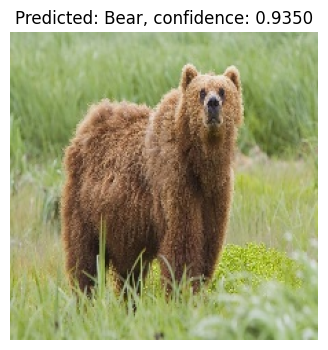

In [27]:
# ============================================
def load_model_for_inference(model_path: Path, device):
    """Load a saved checkpoint and return the model ready for inference (eval mode, no grad)."""
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    loaded_class_names = checkpoint["class_names"]
    loaded_num_classes = checkpoint["num_classes"]
    loaded_img_size = checkpoint["img_size"]
    loaded_mean = checkpoint["mean"]
    loaded_std = checkpoint["std"]

    # pretrained=False here, because all weights are loaded from checkpoint.
    loaded_model = build_resnet18_model(
        num_classes=loaded_num_classes,
        pretrained=False,
        freeze_backbone=False
    )

    loaded_model.load_state_dict(checkpoint["model_state_dict"])
    loaded_model = loaded_model.to(device)
    loaded_model.eval()

    print("Loaded model successfully.")
    print("Loaded classes:", loaded_class_names)
    print("Best validation accuracy in checkpoint:", round(checkpoint.get("best_val_acc", 0), 4))

    return loaded_model, loaded_class_names, loaded_img_size, loaded_mean, loaded_std


def predict_image(image_path, model, class_names, img_size, mean, std, device):
    """Open a single image, apply inference transform, and return (predicted_class, confidence)."""
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence, predicted_idx = torch.max(probabilities, dim=1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item()

    return predicted_class, confidence


loaded_model, loaded_class_names, loaded_img_size, loaded_mean, loaded_std = load_model_for_inference(
    MODEL_PATH,
    device
)

# Find one sample image from dataset for prediction
valid_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
sample_image = None

for ext in valid_extensions:
    found_images = list(DATA_DIR.glob(f"*/*{ext[1:]}"))
    if len(found_images) > 0:
        sample_image = found_images[0]
        break

if sample_image is not None:
    predicted_class, confidence = predict_image(
        sample_image,
        loaded_model,
        loaded_class_names,
        loaded_img_size,
        loaded_mean,
        loaded_std,
        device
    )

    print("Sample image:", sample_image)
    print("Predicted class:", predicted_class)
    print("Confidence:", round(confidence, 4))

    image = Image.open(sample_image).convert("RGB")
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Predicted: {predicted_class}, confidence: {confidence:.4f}")
    plt.axis("off")
    plt.show()
else:
    print("No sample image found.")
    print("Use: predict_image('your_image_path.jpg', loaded_model, loaded_class_names, loaded_img_size, loaded_mean, loaded_std, device)")